### Introduction to Clustering Approach

In this analysis, we apply two unsupervised clustering algorithms:
- K-means clustering
- Hierarchical clustering

For identify clinically meaningful subgroups within our ICU patient cohort.

K-means was selected as the primary method, consistent with established practices in clinical phenotyping studies, which leveraged K-means to define distinct patient profiles based on organ dysfunction markers and laboratory values.

In addition, we use hierarchical clustering to explore the data structure without assuming spherical clusters, and to visualize patient similarities via a dendrogram.

 This complementary approach helps ensure that the identified clusters are robust under different modeling assumptions, an important consideration given the inherent heterogeneity of clinical data. By employing both algorithms, we aim to validate the stability and interpretability of the patient subgroups uncovered in this dataset.



In [1]:
# === File system and utility handling ===
import os
import sys
import shutil
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# === Data manipulation ===
import pandas as pd
import numpy as np

# === Google Drive integration (Colab only) ===
from google.colab import drive
from google.colab import files

# === Plotting and visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Clustering ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

### Load and Prepare Data

In [2]:
!wget https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/main/Preprocessing.py

--2025-07-14 14:47:31--  https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/main/Preprocessing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7242 (7.1K) [text/plain]
Saving to: ‘Preprocessing.py’

Preprocessing.py    100%[===================>]   7.07K  --.-KB/s    in 0s      

2025-07-14 14:47:31 (63.6 MB/s) - ‘Preprocessing.py’ saved [7242/7242]



Import & Load Data

In [3]:
# Import preprocessing
from Preprocessing import build_pipeline, filter_age, remove_rows_with_many_missing

In [4]:
# Load the data
url = "https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/refs/heads/main/MIMIC_data_sample_mortality.csv"
df = pd.read_csv(url)

Clean Data

In [5]:
# Clean your dataframe of bad rows all at once:
df_clean = (
    df
    .pipe(filter_age)
    .pipe(remove_rows_with_many_missing))

Build Pipeline

In [6]:
# Build pipeline
pipeline_builder = build_pipeline()
pipe = pipeline_builder(df_clean)

Fit-Transform Data

In [7]:
# Fit on full data and transform
X_cluster = pipe.fit_transform(df_clean)

Get Feature Names From ColumnTransformer

In [8]:
feature_names = []

for name, transformer, cols in pipe.named_steps['transform'].transformers_:
    if name == 'impute_and_scale':
        feature_names.extend(cols)
    elif name == 'binary_passthrough':
        feature_names.extend(cols)

Build DataFrame With Feature Names

In [9]:
X_cluster_df = pd.DataFrame(X_cluster, columns=feature_names)

Drop outcome variables so they are not used to form clusters

In [10]:
X_cluster_only = X_cluster_df.drop(columns=['thirtyday_expire_flag', 'icu_los'])

### K-means clustering

In [11]:
X_cluster_only_kmeans = X_cluster_only.copy()
X_cluster_df_kmeans = X_cluster_df.copy()

**Determining the optimal number of clusters using the Elbow and Silhouette methods**


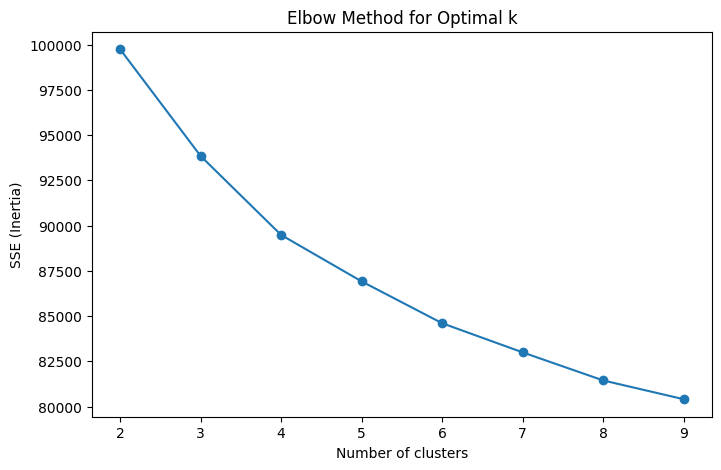

In [12]:
# Elbow method to find optimal k
sse = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_only_kmeans)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('SSE (Inertia)')
plt.show()

The elbow plot suggests an optimal choice of around 3 clusters. We’ll verify this by checking the silhouette scores

In [13]:
# Silhouette score for a quick check
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster_only_kmeans)
    sil = silhouette_score(X_cluster_only_kmeans, labels)
    print(f'Silhouette score for k={k}: {sil:.4f}')

Silhouette score for k=2: 0.0984
Silhouette score for k=3: 0.0665
Silhouette score for k=4: 0.0678
Silhouette score for k=5: 0.0516


Given the small differences in silhouette scores between k=3 and k=4, and the exploratory goal of identifying clinically meaningful subgroups, we will examine both clustering solutions

**Fit the final models for k=3**

In [14]:
# Fit KMeans with k=3
kmeans3 = KMeans(n_clusters=3, random_state=42)
X_cluster_only_kmeans['cluster_3'] = kmeans3.fit_predict(X_cluster)

**Fit the final models for k=4**

In [15]:
# Fit KMeans with k=4
kmeans4 = KMeans(n_clusters=4, random_state=42)
X_cluster_only_kmeans['cluster_4'] = kmeans4.fit_predict(X_cluster)

**Summarize clusters**

K = 3

In [16]:
print(X_cluster_only_kmeans.groupby('cluster_3').mean())

                age      sofa  creatinine_max  chloride_max  glucose_max  \
cluster_3                                                                  
0         -0.938760 -0.275788       -0.515558      0.222785    -0.085923   
1          0.223235  0.922698        1.042127      0.108333     0.513918   
2          0.585936 -0.366559       -0.256129     -0.240437    -0.256524   

           hemoglobin_max  lactate_max  platelet_min  potassium_min  \
cluster_3                                                             
0                0.379971     0.029050     -0.059456      -0.412541   
1               -0.088100     0.620051     -0.266116       0.425215   
2               -0.238581    -0.412174      0.213249       0.051901   

           potassium_max  ...  age_rounded   is_male  race_white  race_black  \
cluster_3                 ...                                                  
0              -0.271866  ...    -0.927807  0.601637    0.640518    0.090041   
1               0.66063

K = 4

In [17]:
print(X_cluster_only_kmeans.groupby('cluster_4').mean())

                age      sofa  creatinine_max  chloride_max  glucose_max  \
cluster_4                                                                  
0          0.608900 -0.347843       -0.317876     -0.133784    -0.432146   
1          0.214879  0.187101        0.080266      0.025028     1.191360   
2          0.202555  1.032845        1.454717     -0.110375    -0.142685   
3         -1.048013 -0.322707       -0.537434      0.217218    -0.240585   

           hemoglobin_max  lactate_max  platelet_min  potassium_min  \
cluster_4                                                             
0               -0.256155    -0.419212      0.158485      -0.010494   
1                0.214966     0.393544      0.018131      -0.010882   
2               -0.305577     0.463519     -0.265869       0.706536   
3                0.350618    -0.039488     -0.052445      -0.406068   

           potassium_max  ...  age_rounded   is_male  race_white  race_black  \
cluster_4                 ...       

**Mortality rates across identified clusters**

In [18]:
X_cluster_df_kmeans['cluster_3'] = X_cluster_only_kmeans['cluster_3']
X_cluster_df_kmeans['cluster_4'] = X_cluster_only_kmeans['cluster_4']

K = 3

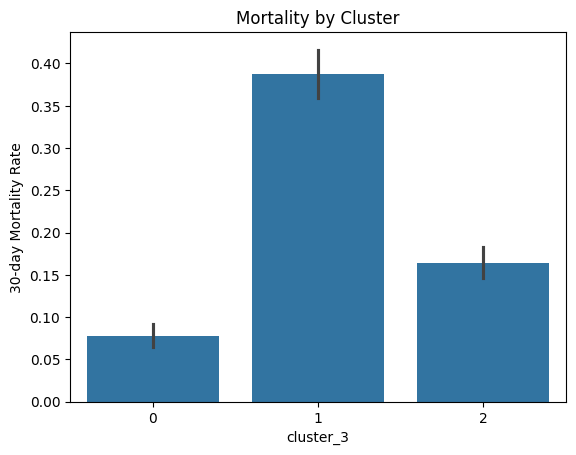

In [19]:
sns.barplot(x='cluster_3', y='thirtyday_expire_flag', data=X_cluster_df_kmeans)
plt.ylabel('30-day Mortality Rate')
plt.title('Mortality by Cluster')
plt.show()

The plot shows that mortality rates differ substantially across the clusters.
Cluster 1 exhibits the highest 30-day mortality, suggesting it represents the sickest patient group,
while Cluster 0 has the lowest mortality.


K = 4

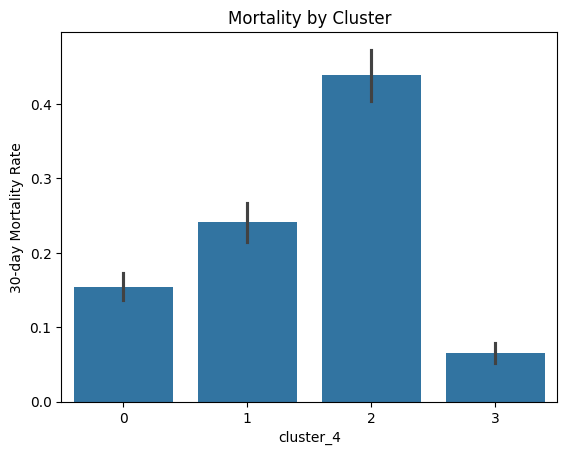

In [20]:
sns.barplot(x='cluster_4', y='thirtyday_expire_flag', data=X_cluster_df_kmeans)
plt.ylabel('30-day Mortality Rate')
plt.title('Mortality by Cluster')
plt.show()

The plot shows that mortality rates vary substantially across the 4 clusters.
Cluster 2 has the highest 30-day mortality (over 40%), suggesting it captures the most critically ill patients.
Cluster 3 have notably lower mortality rate, indicating he represent lower-risk subgroups

**ICU length of stay across clusters**

K = 3

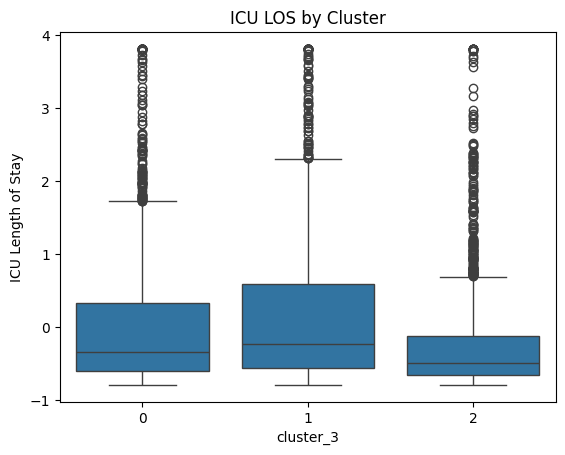

In [21]:
sns.boxplot(x='cluster_3', y='icu_los', data=X_cluster_df_kmeans)
plt.ylabel('ICU Length of Stay')
plt.title('ICU LOS by Cluster')
plt.show()

This boxplot shows that ICU length of stay tends to be slightly higher in Cluster 1,
which also had the highest mortality, suggesting it may capture patients with more severe or prolonged illness.
Clusters 0 and 2 have somewhat lower median stays.

K = 4

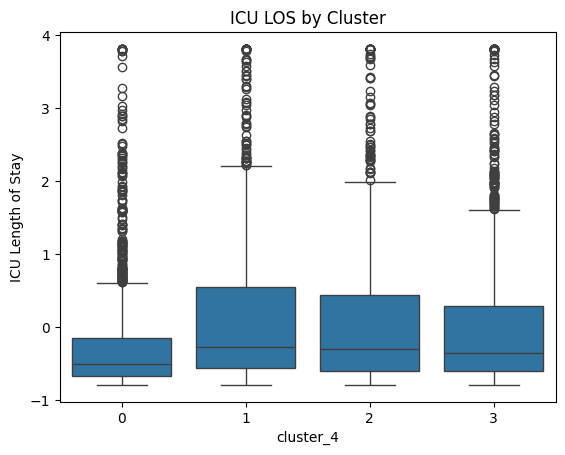

In [22]:
sns.boxplot(x='cluster_4', y='icu_los', data=X_cluster_df_kmeans)
plt.ylabel('ICU Length of Stay')
plt.title('ICU LOS by Cluster')
plt.show()

ICU length of stay appears moderately higher in Clusters 1 and 2, which also showed elevated mortality.
Clusters 0 and 3 have shorter stays, suggesting they represent lower-risk groups with faster ICU discharge

**Mean mortality and ICU length of stay by cluster**

In [50]:
print(X_cluster_df_kmeans.groupby('cluster_3')[['thirtyday_expire_flag', 'icu_los']].mean())

           thirtyday_expire_flag   icu_los
cluster_3                                 
0                       0.077763  0.087459
1                       0.387909  0.246899
2                       0.164116 -0.222835


Cluster 1 has the highest 30-day mortality rate (38.7%) and also the longest ICU stays,
suggesting it captures a higher-risk patient group.
Cluster 0 has the lowest mortality, while Cluster 2 appears intermediate in mortality but with slightly shorter ICU stays.


In [24]:
print(X_cluster_df_kmeans.groupby('cluster_4')[['thirtyday_expire_flag', 'icu_los']].mean())

           thirtyday_expire_flag   icu_los
cluster_4                                 
0                       0.154135 -0.244402
1                       0.240821  0.192263
2                       0.439216  0.155242
3                       0.064822  0.073731


With 4 clusters, Cluster 2 shows the highest mortality rate (43.9%), while Cluster 0 and Cluster 3 have notably lower mortality.
ICU length of stay differences are modest across clusters, suggesting that the primary distinction in this solution is mortality risk

**Characterization of clinical clusters and identification of key risk factors**

In [52]:
print(X_cluster_df_kmeans.groupby('cluster_3')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].mean())

               sofa  lactate_max  creatinine_max       age  bun_mean  \
cluster_3                                                              
0         -0.275788     0.029050       -0.515558 -0.938760 -0.754623   
1          0.922698     0.620051        1.042127  0.223235  0.969153   
2         -0.366559    -0.412174       -0.256129  0.585936 -0.025321   

           urineoutput  hemoglobin_max      vent  glucose_mean  spo2_mean  
cluster_3                                                                  
0             0.528831        0.379971  0.685539     -0.121708   0.261773  
1            -0.747371       -0.088100  0.627204      0.416578  -0.157659  
2             0.060608       -0.238581  0.408971     -0.167662  -0.103424  


In [26]:
print(X_cluster_df_kmeans.groupby('cluster_4')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].mean())

               sofa  lactate_max  creatinine_max       age  bun_mean  \
cluster_4                                                              
0         -0.347843    -0.419212       -0.317876  0.608900 -0.097966   
1          0.187101     0.393544        0.080266  0.214879  0.259031   
2          1.032845     0.463519        1.454717  0.202555  1.236596   
3         -0.322707    -0.039488       -0.537434 -1.048013 -0.813838   

           urineoutput  hemoglobin_max      vent  glucose_mean  spo2_mean  
cluster_4                                                                  
0             0.071498       -0.256155  0.427318     -0.408003  -0.043301  
1            -0.009180        0.214966  0.600432      1.313608  -0.120276  
2            -1.034300       -0.305577  0.559477     -0.263034  -0.231293  
3             0.541999        0.350618  0.680632     -0.287753   0.282548  


**Deciding between 3 and 4 clusters based on t-SNE visualization**

After completing all statistical checks and cluster summaries for k=3 and k=4, we use t-SNE visualization to assess how well-separated the clusters appear in local structure. This helps guide our final choice of the most meaningful clustering solution.

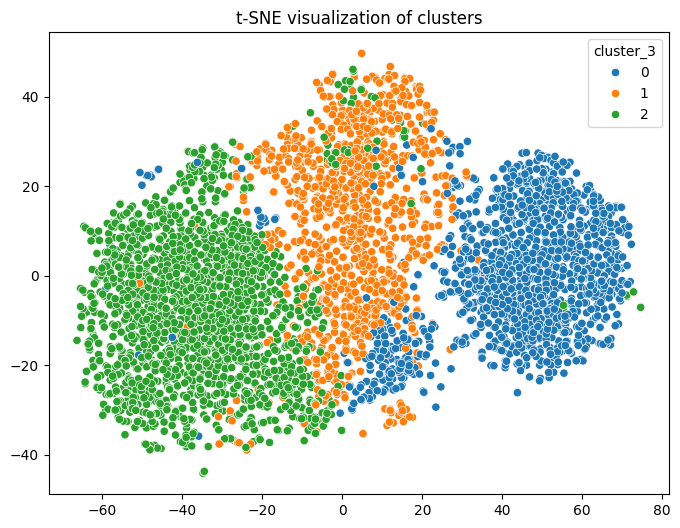

In [27]:
from sklearn.manifold import TSNE

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_cluster_only_kmeans)

# Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_cluster_df_kmeans['cluster_3'], palette='tab10')
plt.title('t-SNE visualization of clusters')
plt.show()

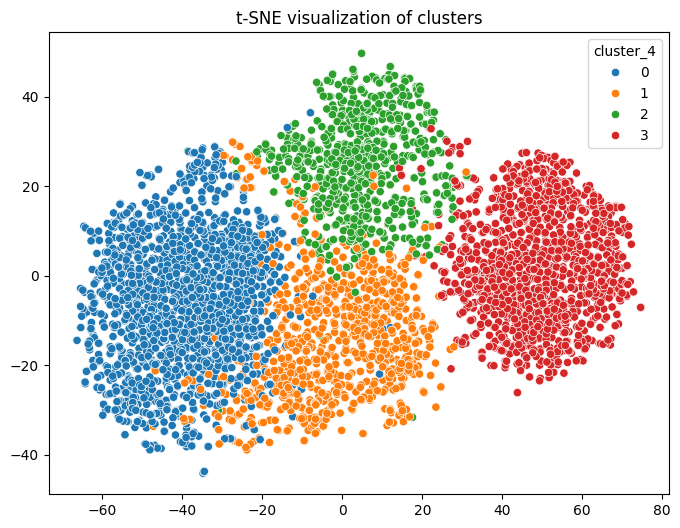

In [28]:
# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_cluster_only_kmeans)

# Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_cluster_df_kmeans['cluster_4'], palette='tab10')
plt.title('t-SNE visualization of clusters')
plt.show()

Based on our comprehensive analysis, including the elbow and silhouette methods, detailed clinical summaries of key features, and finally the t-SNE visualization of local cluster structure, we decided to proceed with 4 clusters (k=4).

The t-SNE plots demonstrated that the fourth cluster formed a well-separated, distinct group, suggesting it captures an important clinical phenotype that would have been masked in a simpler three-cluster solution. This provides a more nuanced stratification of our ICU cohort, which we will explore in subsequent analyses.

**Compare clusters on key variable**

In [54]:
cluster_summary = X_cluster_df_kmeans.groupby('cluster_4')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].agg(['mean', 'std'])
print(cluster_summary)

               sofa           lactate_max           creatinine_max            \
               mean       std        mean       std           mean       std   
cluster_4                                                                      
0         -0.347843  0.838379   -0.419212  0.707716      -0.317876  0.613809   
1          0.187101  0.975394    0.393544  1.047393       0.080266  0.784378   
2          1.032845  0.740471    0.463519  1.195648       1.454717  1.056243   
3         -0.322707  0.870867   -0.039488  0.914003      -0.537434  0.546926   

                age            bun_mean           urineoutput            \
               mean       std      mean       std        mean       std   
cluster_4                                                                 
0          0.608900  0.638229 -0.097966  0.739966    0.071498  0.715017   
1          0.214879  0.757135  0.259031  0.806327   -0.009180  0.857274   
2          0.202555  0.881544  1.236596  0.743762   -1.034300  1

- Cluster 2

    Highest SOFA, lactate, creatinine, BUN — generally looks like the sickest group.

    Lower urine output, lower SpO2.

    More ventilation.

    Matches highest mortality.

- Cluster 3

    Lower SOFA & lactate, slightly better kidney markers.

    But interestingly has higher urine output & slightly higher SpO2.

    Looks like an older group (age is lowest negative z-score) with possibly different risk profile.

- Cluster 0

    Mid-range SOFA, moderate labs, not extreme on any feature.

    Could be an intermediate-risk group.

- Cluster 1

    Generally lower creatinine & lactate, higher urine output, best glucose.

    Likely the lowest risk group.

**Test statistical differences**

ANOVA for continuous variables

In [30]:
from scipy.stats import f_oneway

for col in ['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean',
            'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean', 'icu_los']:
    fval, pval = f_oneway(
        X_cluster_df_kmeans.loc[X_cluster_df_kmeans['cluster_4'] == 0, col],
        X_cluster_df_kmeans.loc[X_cluster_df_kmeans['cluster_4'] == 1, col],
        X_cluster_df_kmeans.loc[X_cluster_df_kmeans['cluster_4'] == 2, col],
        X_cluster_df_kmeans.loc[X_cluster_df_kmeans['cluster_4'] == 3, col]
    )
    print(f"ANOVA p-value for {col}: {pval:.4f}")

ANOVA p-value for sofa: 0.0000
ANOVA p-value for lactate_max: 0.0000
ANOVA p-value for creatinine_max: 0.0000
ANOVA p-value for age: 0.0000
ANOVA p-value for bun_mean: 0.0000
ANOVA p-value for urineoutput: 0.0000
ANOVA p-value for hemoglobin_max: 0.0000
ANOVA p-value for vent: 0.0000
ANOVA p-value for glucose_mean: 0.0000
ANOVA p-value for spo2_mean: 0.0000
ANOVA p-value for icu_los: 0.0000


Chi-squared for categorical (e.g. ventilation, cancer)

In [31]:
import scipy.stats as stats

# For ventilation
contingency_table_vent = pd.crosstab(X_cluster_df_kmeans['cluster_4'], X_cluster_df_kmeans['vent'])
chi2_vent, p_vent, _, _ = stats.chi2_contingency(contingency_table_vent)
print(f"Chi-squared p-value for ventilation across clusters: {p_vent:.4f}")

# For 30-day mortality
contingency_table_mort = pd.crosstab(X_cluster_df_kmeans['cluster_4'], X_cluster_df_kmeans['thirtyday_expire_flag'])
chi2_mort, p_mort, _, _ = stats.chi2_contingency(contingency_table_mort)
print(f"Chi-squared p-value for 30-day mortality across clusters: {p_mort:.4f}")

Chi-squared p-value for ventilation across clusters: 0.0000
Chi-squared p-value for 30-day mortality across clusters: 0.0000


We performed ANOVA tests across the four identified clusters, finding statistically significant differences (p < 0.0001) in all key clinical features, including SOFA scores, lactate, creatinine, age, and ICU length of stay.
Similarly, chi-squared tests revealed significant differences in both ventilation usage and 30-day mortality rates across clusters (p < 0.0001).
These results suggest that the clustering meaningfully stratifies patients into clinically distinct subgroups.

**Determining which clusters differ significantly: pairwise statistical tests**

Tukey HSD for continuous variables

In [59]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# List of continuous variables
continuous_vars = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
                   'urineoutput', 'hemoglobin_max', 'glucose_mean', 'spo2_mean', 'icu_los']

# Loop through and run Tukey HSD for each
for var in continuous_vars:
    tukey = pairwise_tukeyhsd(endog=X_cluster_df_kmeans[var],
                              groups=X_cluster_df_kmeans['cluster_4'],
                              alpha=0.05)
    print(f"\nTukey HSD results for {var}:")
    print(tukey.summary())


Tukey HSD results for sofa:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.5349    0.0  0.4434  0.6264   True
     0      2   1.3807    0.0  1.2833  1.4781   True
     0      3   0.0251 0.8659 -0.0582  0.1085  False
     1      2   0.8457    0.0  0.7375   0.954   True
     1      3  -0.5098    0.0 -0.6056  -0.414   True
     2      3  -1.3556    0.0  -1.457 -1.2541   True
----------------------------------------------------

Tukey HSD results for lactate_max:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.8128    0.0  0.7137  0.9118   True
     0      2   0.8827    0.0  0.7773  0.9882   True
     0      3   0.3797    0.0  0.2894    0.47   True
     1      2     0.07 0.4168 -0.0472  0.1872  False
     1      3   -0.433    0.0 -0.5

categorical outcomes (mortality, ventilation)

In [61]:
from scipy.stats import chi2_contingency

categorical_vars = ['thirtyday_expire_flag', 'vent']
clusters = X_cluster_df_kmeans['cluster_4'].unique()

for var in categorical_vars:
    print(f"\nPairwise chi-squared tests for {var}:")
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            subset = X_cluster_df_kmeans[X_cluster_df_kmeans['cluster_4'].isin([clusters[i], clusters[j]])]
            contingency_table = pd.crosstab(subset['cluster_4'], subset[var])
            chi2, p, _, _ = chi2_contingency(contingency_table)
            print(f"Clusters {clusters[i]} vs {clusters[j]}: p-value = {p:.4f}")


Pairwise chi-squared tests for thirtyday_expire_flag:
Clusters 2 vs 1: p-value = 0.0000
Clusters 2 vs 0: p-value = 0.0000
Clusters 2 vs 3: p-value = 0.0000
Clusters 1 vs 0: p-value = 0.0000
Clusters 1 vs 3: p-value = 0.0000
Clusters 0 vs 3: p-value = 0.0000

Pairwise chi-squared tests for vent:
Clusters 2 vs 1: p-value = 0.0990
Clusters 2 vs 0: p-value = 0.0000
Clusters 2 vs 3: p-value = 0.0000
Clusters 1 vs 0: p-value = 0.0000
Clusters 1 vs 3: p-value = 0.0001
Clusters 0 vs 3: p-value = 0.0000


**Results**

- For continuous variables (Tukey HSD)
    Almost all clusters differ significantly on SOFA, lactate, creatinine, BUN, age, urine output, hemoglobin, glucose, SpO2, and ICU LOS (most p-adj < 0.0001).

    A few exceptions where differences are not significant (for example):

    - SOFA: cluster 0 vs 3 (p=0.8659), meaning similar SOFA.

    - Lactate: cluster 1 vs 2 (p=0.4168).

    - Age: cluster 1 vs 2 (p=0.9864).

    - Glucose: cluster 2 vs 3 (p=0.8877).

    - ICU LOS: cluster 1 vs 2 (p=0.8677), cluster 2 vs 3 (p=0.2687).

- For categorical outcomes (Chi²)
Mortality (thirtyday_expire_flag):

    Extremely strong separation — all cluster pairs differ significantly (p < 0.0001). This shows your clustering stratifies mortality very clearly.



Pairwise comparisons using Tukey HSD and chi-squared tests demonstrated that the four identified clusters differ significantly across nearly all key clinical features, including SOFA, lactate, creatinine, BUN, age, urine output, glucose, SpO2, and ICU length of stay. Mortality rates were significantly different between all cluster pairs (p < 0.0001), while ventilation usage also showed significant differences in most comparisons. This highlights the robustness of our clustering in capturing clinically meaningful patient subgroups

**Visualize clusters**

Boxplots for key features

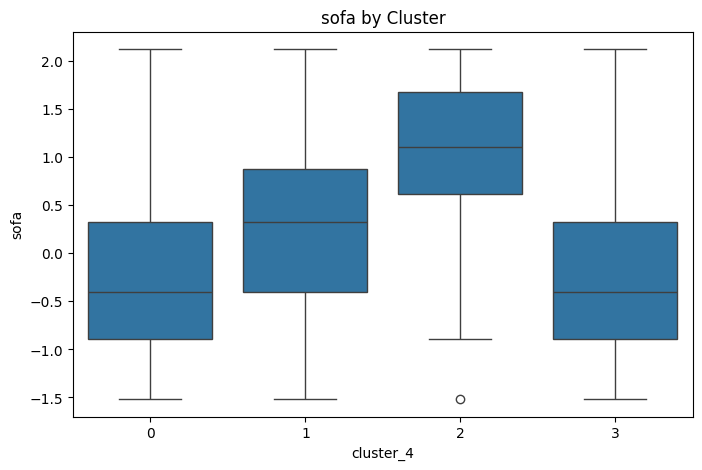

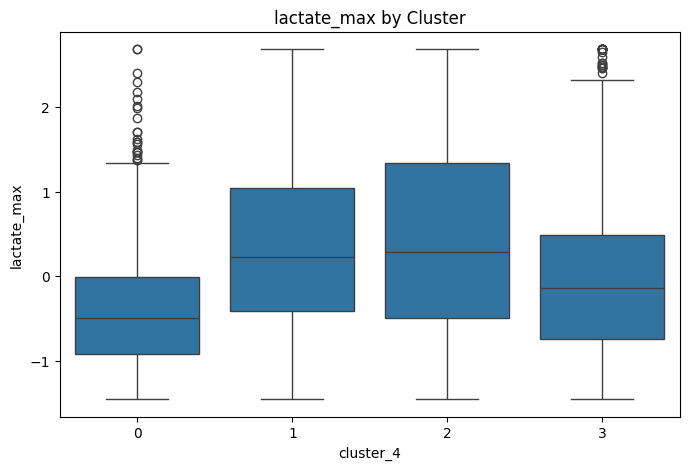

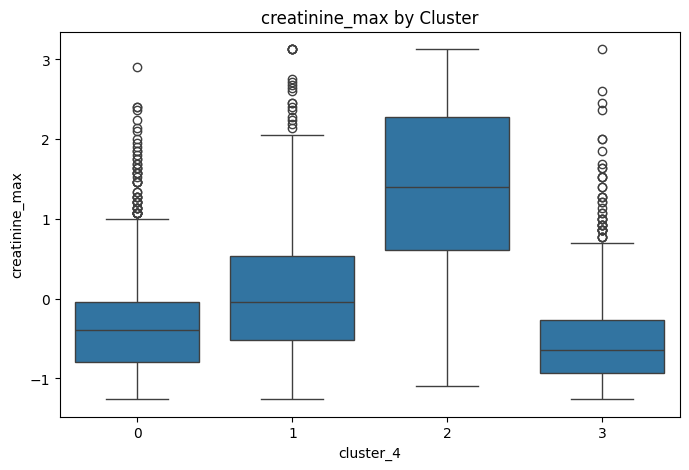

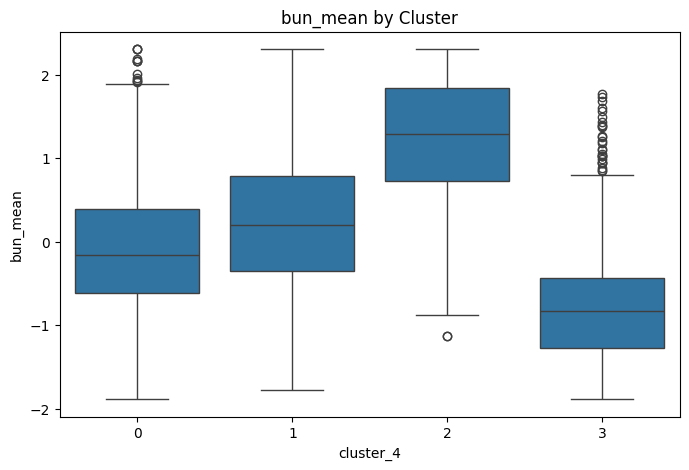

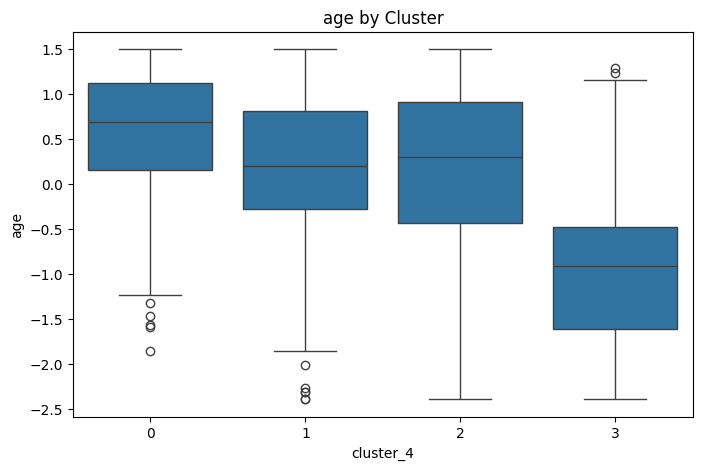

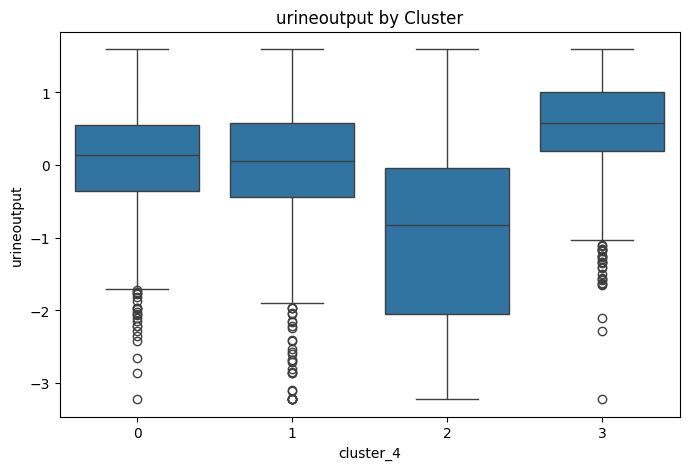

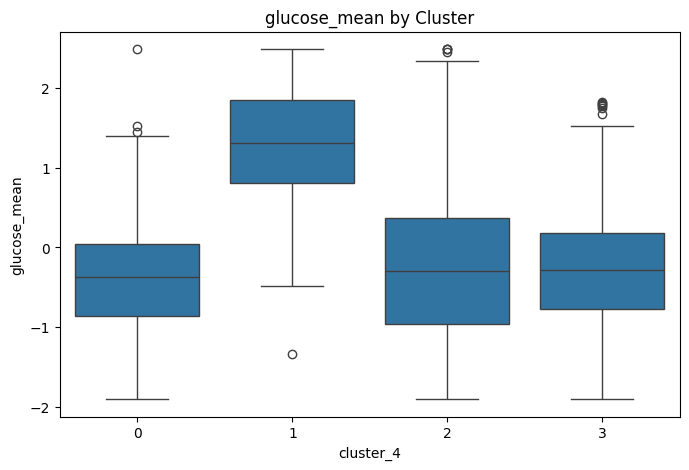

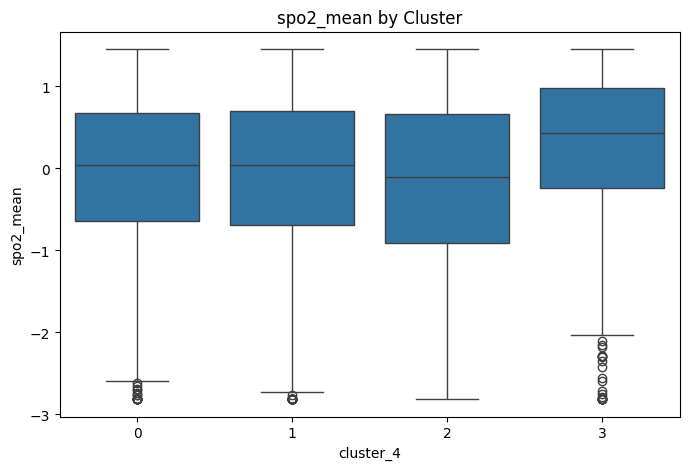

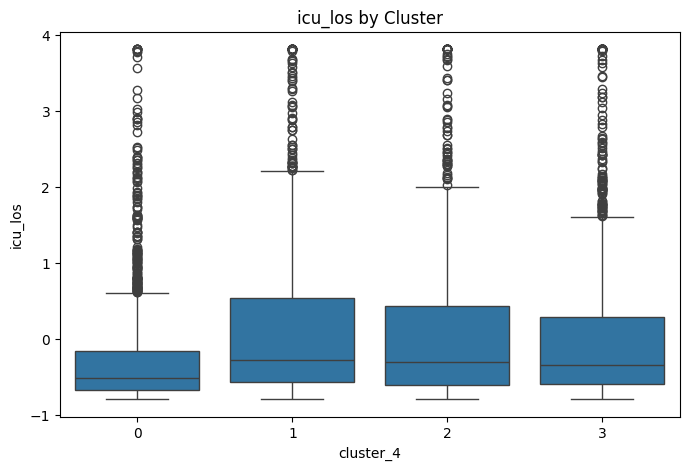

In [34]:
features = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
            'urineoutput', 'glucose_mean', 'spo2_mean', 'icu_los']

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='cluster_4', y=feature, data=X_cluster_df_kmeans)
    plt.title(f"{feature} by Cluster")
    plt.show()

- SOFA: Median SOFA scores are highest in cluster 2 and lowest in cluster 3.

- Lactate & creatinine: Elevated in cluster 2, suggesting worse metabolic and renal profiles.

- BUN & urine output: Cluster 2 again stands out with high BUN and low urine output.

- Age: Cluster 3 includes younger patients, whereas clusters 0 and 1 have higher age ranges.

- Glucose & SpO2: Show moderate differences, with slightly higher glucose in cluster 1.

- ICU length of stay: Longer in clusters 0 and 1, shorter in clusters 3.

**PCA visualization of clusters**





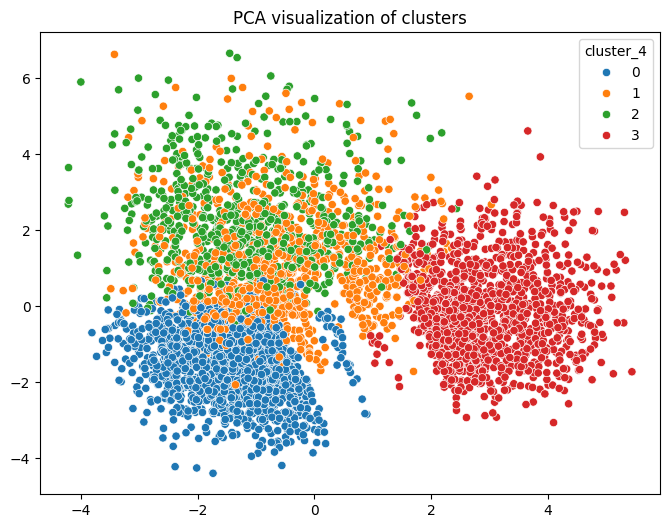

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_only_kmeans)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_cluster_df_kmeans['cluster_4'], palette='tab10')
plt.title('PCA visualization of clusters')
plt.show()

The PCA scatter plot shows a reasonably clear separation between the four clusters, particularly distinguishing cluster 3 (red) from the others. Clusters 0 (blue) and 1 (orange) exhibit some overlap, while cluster 2 (green) is moderately distinct. This supports the t-SNE findings and indicates meaningful group structure in the data

**Clinical interpretation**

Our analysis revealed four distinct clusters of ICU patients based on key clinical and laboratory features. These clusters demonstrate meaningful differences in patient characteristics, organ dysfunction markers, and outcomes:

- Cluster 2

    - Exhibits the highest levels of creatinine_max, BUN, and lactate, indicating significant renal dysfunction and metabolic derangements.

    - Also shows elevated SOFA scores, consistent with more severe multi-organ involvement.

    - This cluster had longer ICU stays and the highest 30-day mortality, highlighting a high-risk patient phenotype.

- Cluster 1

    - Characterized by moderately elevated lactate and SOFA scores, but relatively preserved urine output and lower creatinine levels compared to Cluster 2.

    - Shows intermediate ICU LOS and mortality, suggesting a moderate-risk group, potentially representing early or partially compensated organ dysfunction.

- Cluster 0

    - Displays lower SOFA scores, lower creatinine, and better urine output, consistent with less severe organ dysfunction.

    - Despite slightly older age than Cluster 3, this group had shorter ICU stays and lower mortality, aligning with a lower-risk phenotype.

- Cluster 3

    - Notably had the youngest patients, relatively preserved SOFA and lactate values, and lower BUN.

    - Also demonstrated lower 30-day mortality and shorter ICU LOS, representing a lower-acuity cohort, possibly with transient or isolated insults requiring ICU care.

These findings suggest that unsupervised clustering can effectively identify subgroups of ICU patients with distinct clinical profiles and outcomes. Recognizing these phenotypes may assist clinicians in early risk stratification, targeted monitoring, and potentially tailored therapeutic interventions.


### Hierarchical Clustering

In [36]:
X_cluster_only_hierarchical = X_cluster_only.copy()
X_cluster_df_hierarchical = X_cluster_df.copy()

**Generate a dendrogram to decide k**

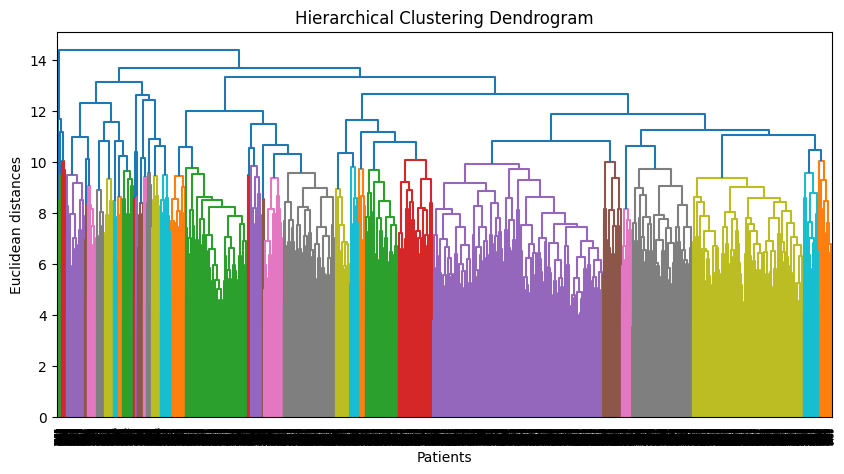

In [37]:
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_cluster_only_hierarchical, method='complete'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Patients')
plt.ylabel('Euclidean distances')
plt.show()

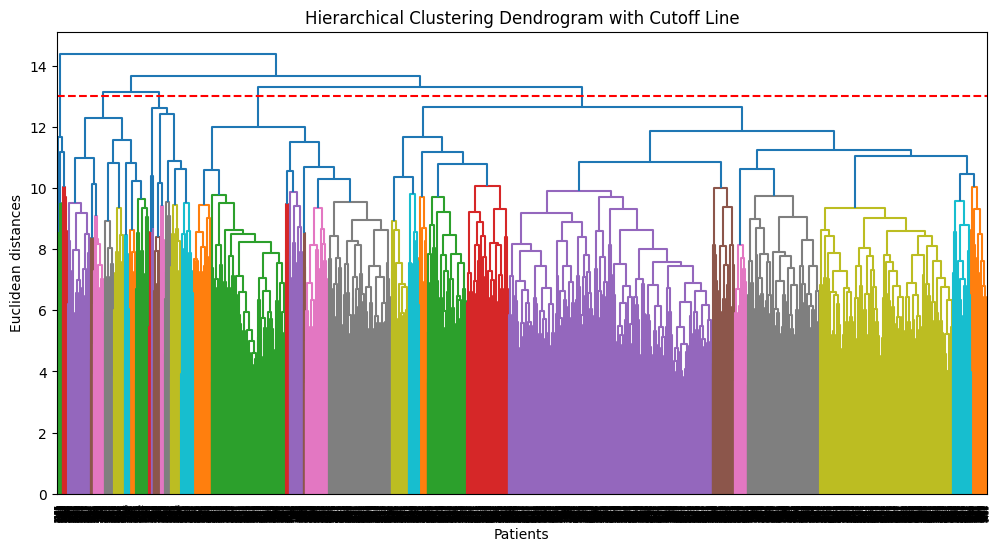

In [38]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(X_cluster_only, method='complete')

plt.figure(figsize=(12, 6))
dend = dendrogram(linkage_matrix)
plt.axhline(y=13, color='r', linestyle='--')
plt.title('Hierarchical Clustering Dendrogram with Cutoff Line')
plt.xlabel('Patients')
plt.ylabel('Euclidean distances')
plt.show()

In [39]:
from scipy.cluster.hierarchy import fcluster

cluster_labels_hierarchical = fcluster(linkage_matrix, t=13, criterion='distance')
print("Number of clusters found:", len(np.unique(cluster_labels_hierarchical)))

Number of clusters found: 5


**Assign hierarchical cluster labels to full dataset for analysis**

In [40]:
X_cluster_df_hierarchical['hier_cluster_5'] = cluster_labels_hierarchical

**Evaluate hierarchical clustering quality with Cophenetic Correlation Coefficient**


In [41]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# Compute cophenetic correlation coefficient
coph_corr, coph_dists = cophenet(linkage_matrix, pdist(X_cluster_only_hierarchical))

print(f"Cophenetic correlation coefficient: {coph_corr:.4f}")

Cophenetic correlation coefficient: 0.3870


The cophenetic correlation coefficient was 0.39, indicating a moderate fit between the hierarchical clustering structure and the original data distances.
To further assess the quality and separation of these clusters, we visualized them using t-SNE, which provides an intuitive view of how the identified patient groups distribute in lower-dimensional space.

**t-SNE**

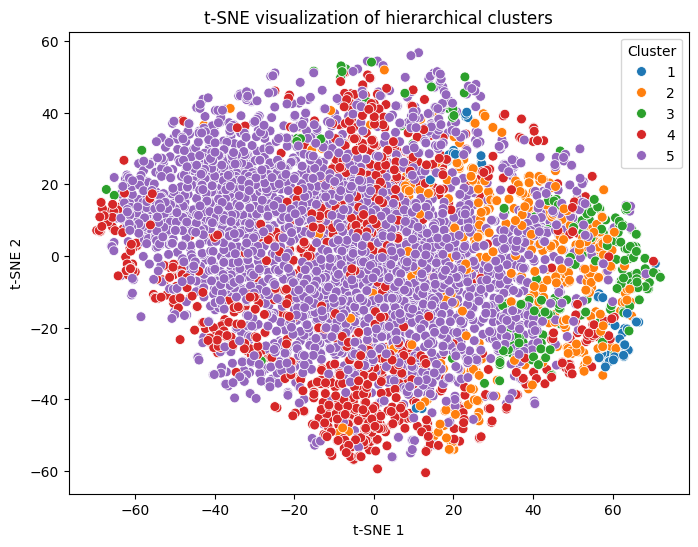

In [43]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_cluster_only_hierarchical)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_cluster_df_hierarchical['hier_cluster_5'], palette='tab10', s=50)
plt.title('t-SNE visualization of hierarchical clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.show()

Based on the dendrogram analysis and the t-SNE projection, we opted to continue with 5 hierarchical clusters.
This allows us to explore more granular patient groupings, potentially uncovering subtle but clinically relevant patterns in physiology, laboratory results, and outcomes.
Despite the imperfect separation, these clusters can guide hypotheses about distinct risk profiles or therapeutic needs in the ICU population.

**Summarize clusters**

In [44]:
print(X_cluster_df_hierarchical.groupby('hier_cluster_5').mean())

                 icu_los       age      sofa  creatinine_max  chloride_max  \
hier_cluster_5                                                               
1               0.231416 -0.297077  1.774282        1.012083      0.308128   
2               0.022376  0.502170  0.793785        1.231019      0.416196   
3               0.089472 -0.145855  1.031498        1.319893     -0.604005   
4               0.107101  0.000506 -0.056488       -0.054856      0.018253   
5              -0.049784 -0.051991 -0.198879       -0.265373     -0.024212   

                glucose_max  hemoglobin_max  lactate_max  platelet_min  \
hier_cluster_5                                                           
1                  1.788538        0.268224     2.126404     -0.842326   
2                  0.287807       -0.356119     0.329945     -0.178011   
3                 -0.354255       -0.371519     0.632317     -0.393869   
4                  0.862432        0.128217     0.203619      0.025770   
5        

In [47]:
X_cluster_df_hierarchical['hier_cluster_5'].value_counts()

,count
hier_cluster_5,
5,2914
4,972
2,396
3,214
1,56


**Mortality rates across identified clusters**

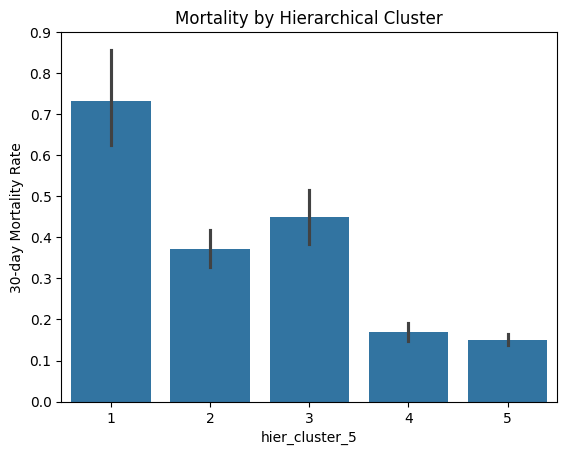

In [48]:
sns.barplot(x='hier_cluster_5', y='thirtyday_expire_flag', data=X_cluster_df_hierarchical)
plt.ylabel('30-day Mortality Rate')
plt.title('Mortality by Hierarchical Cluster')
plt.show()

The plot shows clear mortality differences across the five clusters.

- Cluster 1 has the highest mortality (>70%), indicating the sickest patients.

- Clusters 4 and 5 have the lowest (~15%), suggesting lower risk.

- Clusters 2 and 3 are intermediate.

This suggests the clusters capture meaningful clinical risk groups.

**ICU length of stay across clusters**

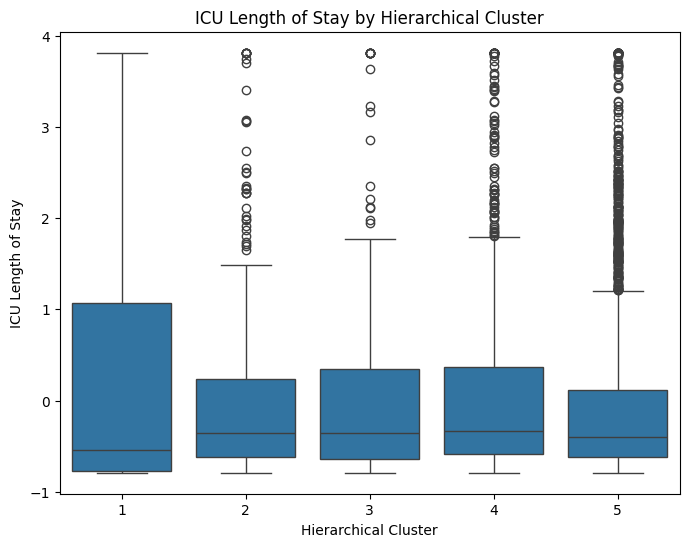

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='hier_cluster_5', y='icu_los', data=X_cluster_df_hierarchical)
plt.xlabel('Hierarchical Cluster')
plt.ylabel('ICU Length of Stay')
plt.title('ICU Length of Stay by Hierarchical Cluster')
plt.show()

The boxplot shows that although Cluster 1 has the lowest median ICU stay, it exhibits a much wider range, with numerous patients experiencing prolonged ICU stays. This suggests that Cluster 1 is a heterogeneous group, potentially including both quickly discharged and very long-stay patients. In contrast, Clusters 2 to 5 have higher medians but narrower distributions, indicating more uniform ICU stays, likely reflecting more consistent illness severities.

**Mean mortality and ICU length of stay by cluster**

In [51]:
print(X_cluster_df_hierarchical.groupby('hier_cluster_5')[['thirtyday_expire_flag', 'icu_los']].mean())

                thirtyday_expire_flag   icu_los
hier_cluster_5                                 
1                            0.732143  0.231416
2                            0.371212  0.022376
3                            0.448598  0.089472
4                            0.168724  0.107101
5                            0.150652 -0.049784


- Cluster 1 shows the highest mean 30-day mortality (73%) and the highest ICU length of stay (0.23), indicating this group likely captures the sickest patients with prolonged critical illness and very high mortality.

- Cluster 3 also has elevated mortality (45%) and moderate ICU stays, suggesting another relatively high-risk group.

- Cluster 2 has intermediate mortality (37%) but very short ICU stays, possibly reflecting patients with early deaths or rapid ICU transitions.

- Clusters 4 and 5 have the lowest mortality rates (17% and 15%) and relatively short ICU stays, indicating these may represent lower-risk groups with quicker ICU recoveries.

**Characterization of clinical clusters and identification of key risk factors**

In [56]:
cluster_summary = X_cluster_df_hierarchical.groupby('hier_cluster_5')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].agg(['mean', 'std'])
print(cluster_summary)

                    sofa           lactate_max           creatinine_max  \
                    mean       std        mean       std           mean   
hier_cluster_5                                                            
1               1.774282  0.414806    2.126404  0.623564       1.012083   
2               0.793785  0.771926    0.329945  1.066028       1.231019   
3               1.031498  0.935774    0.632317  1.381079       1.319893   
4              -0.056488  0.981650    0.203619  0.965263      -0.054856   
5              -0.198879  0.910159   -0.200059  0.875328      -0.265373   

                               age            bun_mean           urineoutput  \
                     std      mean       std      mean       std        mean   
hier_cluster_5                                                                 
1               0.911237 -0.297077  1.024304  0.369983  0.771821   -1.725434   
2               1.118051  0.502170  0.747190  1.151651  0.767775   -0.936073   

- Cluster 1 has the highest SOFA, lactate, creatinine, and glucose, with low urine output and high ventilation — indicating severe multi-organ dysfunction, aligned with its high mortality (73%), despite some within-cluster variability.

- Cluster 2 shows moderately elevated SOFA and creatinine, but lower lactate and higher hemoglobin, suggesting renal involvement without severe shock.

- Cluster 3 presents with high creatinine and glucose, moderate SOFA and lactate, plus elevated ventilation, reflecting metabolic and respiratory stress.

- Clusters 4 and 5 have the lowest SOFA, lactate, and creatinine, near-normal labs, and less ventilation, consistent with lower severity and mortality.

**Test statistical differences**

ANOVA for continuous variables

In [57]:
from scipy.stats import f_oneway

for col in ['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean',
            'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean', 'icu_los']:
    fval, pval = f_oneway(
        X_cluster_df_hierarchical.loc[X_cluster_df_hierarchical['hier_cluster_5'] == 1, col],
        X_cluster_df_hierarchical.loc[X_cluster_df_hierarchical['hier_cluster_5'] == 2, col],
        X_cluster_df_hierarchical.loc[X_cluster_df_hierarchical['hier_cluster_5'] == 3, col],
        X_cluster_df_hierarchical.loc[X_cluster_df_hierarchical['hier_cluster_5'] == 4, col],
        X_cluster_df_hierarchical.loc[X_cluster_df_hierarchical['hier_cluster_5'] == 5, col],
    )
    print(f"ANOVA p-value for {col}: {pval:.4f}")

ANOVA p-value for sofa: 0.0000
ANOVA p-value for lactate_max: 0.0000
ANOVA p-value for creatinine_max: 0.0000
ANOVA p-value for age: 0.0000
ANOVA p-value for bun_mean: 0.0000
ANOVA p-value for urineoutput: 0.0000
ANOVA p-value for hemoglobin_max: 0.0000
ANOVA p-value for vent: 0.0000
ANOVA p-value for glucose_mean: 0.0000
ANOVA p-value for spo2_mean: 0.0000
ANOVA p-value for icu_los: 0.0001


Chi-squared for categorical

In [58]:
# For ventilation
contingency_table_vent = pd.crosstab(X_cluster_df_hierarchical['hier_cluster_5'], X_cluster_df_hierarchical['vent'])
chi2_vent, p_vent, _, _ = stats.chi2_contingency(contingency_table_vent)
print(f"Chi-squared p-value for ventilation across clusters: {p_vent:.4f}")

# For 30-day mortality
contingency_table_mort = pd.crosstab(X_cluster_df_hierarchical['hier_cluster_5'], X_cluster_df_hierarchical['thirtyday_expire_flag'])
chi2_mort, p_mort, _, _ = stats.chi2_contingency(contingency_table_mort)
print(f"Chi-squared p-value for 30-day mortality across clusters: {p_mort:.4f}")


Chi-squared p-value for ventilation across clusters: 0.0000
Chi-squared p-value for 30-day mortality across clusters: 0.0000


We found statistically significant differences (p < 0.0001) across all evaluated clinical variables and outcomes, including organ dysfunction scores, laboratory parameters, ventilation use, and mortality. This supports that the hierarchical clustering meaningfully stratified patients into distinct clinical phenotypes.

**Determining which clusters differ significantly: pairwise statistical tests**

Tukey HSD for continuous variables

In [60]:
# List of continuous variables
continuous_vars = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
                   'urineoutput', 'hemoglobin_max', 'glucose_mean', 'spo2_mean', 'icu_los']

# Loop through and run Tukey HSD for each
for var in continuous_vars:
    tukey = pairwise_tukeyhsd(endog=X_cluster_df_hierarchical[var],
                              groups=X_cluster_df_hierarchical['hier_cluster_5'],
                              alpha=0.05)
    print(f"\nTukey HSD results for {var}:")
    print(tukey.summary())


Tukey HSD results for sofa:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.9805    0.0 -1.3357 -0.6253   True
     1      3  -0.7428    0.0 -1.1163 -0.3693   True
     1      4  -1.8308    0.0 -2.1727 -1.4888   True
     1      5  -1.9732    0.0 -2.3088 -1.6375   True
     2      3   0.2377 0.0182  0.0266  0.4488   True
     2      4  -0.8503    0.0 -0.9986 -0.7019   True
     2      5  -0.9927    0.0 -1.1259 -0.8594   True
     3      4   -1.088    0.0 -1.2759 -0.9001   True
     3      5  -1.2304    0.0 -1.4066 -1.0542   True
     4      5  -0.1424 0.0002 -0.2346 -0.0502   True
----------------------------------------------------

Tukey HSD results for lactate_max:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -1.7965    0.0 -2.1

In [63]:
categorical_vars = ['thirtyday_expire_flag', 'vent']
clusters = X_cluster_df_hierarchical['hier_cluster_5'].unique()

for var in categorical_vars:
    print(f"\nPairwise chi-squared tests for {var}:")
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            subset = X_cluster_df_hierarchical[X_cluster_df_hierarchical['hier_cluster_5'].isin([clusters[i], clusters[j]])]
            contingency_table = pd.crosstab(subset['hier_cluster_5'], subset[var])
            chi2, p, _, _ = chi2_contingency(contingency_table)
            print(f"Clusters {clusters[i]} vs {clusters[j]}: p-value = {p:.4f}")


Pairwise chi-squared tests for thirtyday_expire_flag:
Clusters 3 vs 5: p-value = 0.0000
Clusters 3 vs 2: p-value = 0.0757
Clusters 3 vs 1: p-value = 0.0003
Clusters 3 vs 4: p-value = 0.0000
Clusters 5 vs 2: p-value = 0.0000
Clusters 5 vs 1: p-value = 0.0000
Clusters 5 vs 4: p-value = 0.1948
Clusters 2 vs 1: p-value = 0.0000
Clusters 2 vs 4: p-value = 0.0000
Clusters 1 vs 4: p-value = 0.0000

Pairwise chi-squared tests for vent:
Clusters 3 vs 5: p-value = 0.9334
Clusters 3 vs 2: p-value = 0.5585
Clusters 3 vs 1: p-value = 0.0000
Clusters 3 vs 4: p-value = 0.0013
Clusters 5 vs 2: p-value = 0.2251
Clusters 5 vs 1: p-value = 0.0000
Clusters 5 vs 4: p-value = 0.0000
Clusters 2 vs 1: p-value = 0.0000
Clusters 2 vs 4: p-value = 0.0000
Clusters 1 vs 4: p-value = 0.0000


**Results**

Tukey HSD results for continuous variables:

- Significant pairwise differences (p < 0.05) were found across most cluster comparisons for SOFA, lactate, creatinine, BUN, hemoglobin, glucose, and SpO₂, confirming substantial heterogeneity in organ dysfunction, metabolic markers, and oxygenation across clusters.

- For age, differences were mainly driven by Cluster 2 being older than others.

- Urine output showed strong differences especially between Cluster 1 (lowest output) and others.

- ICU LOS differences were generally not significant between most clusters, except a modest difference between Clusters 4 and 5.

Chi-squared pairwise tests for categorical outcomes:

- 30-day mortality showed significant differences (p < 0.05) between nearly all cluster pairs, except between Clusters 3 vs 2 and 5 vs 4 (where p > 0.05).

- Ventilation rates also differed significantly across most cluster pairs, with no significant differences for pairs like Clusters 3 vs 5 or 5 vs 2.

Overall, these results confirm that the hierarchical clustering meaningfully stratified patients into distinct clinical phenotypes.
Clusters differ significantly in most key physiological and laboratory markers, as well as in 30-day mortality and ventilation needs, supporting the clinical relevance of the derived groups.

**Visualize clusters**

Boxplots for key features

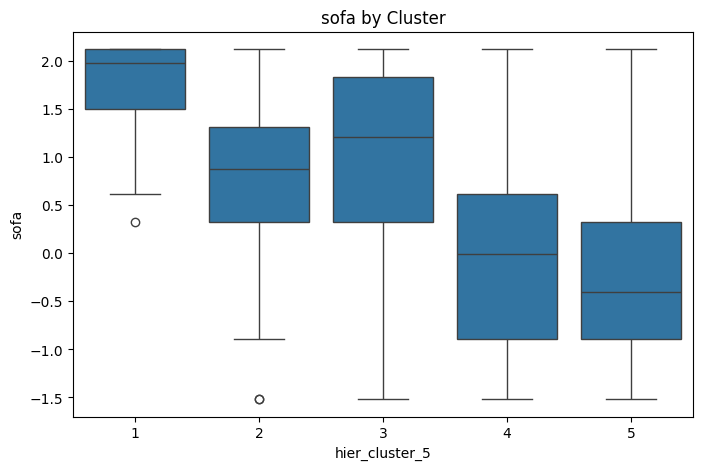

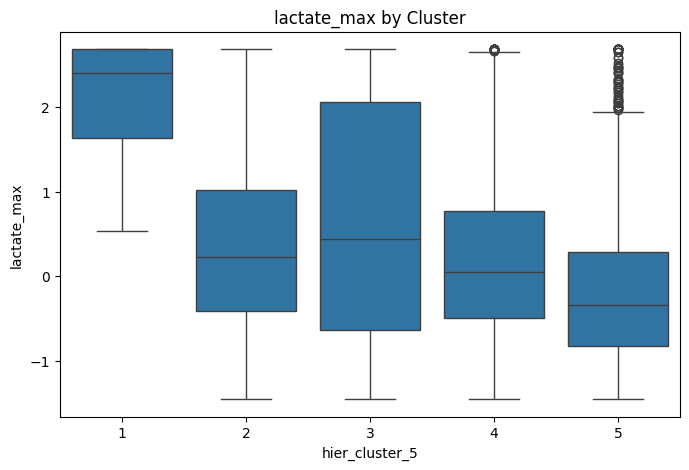

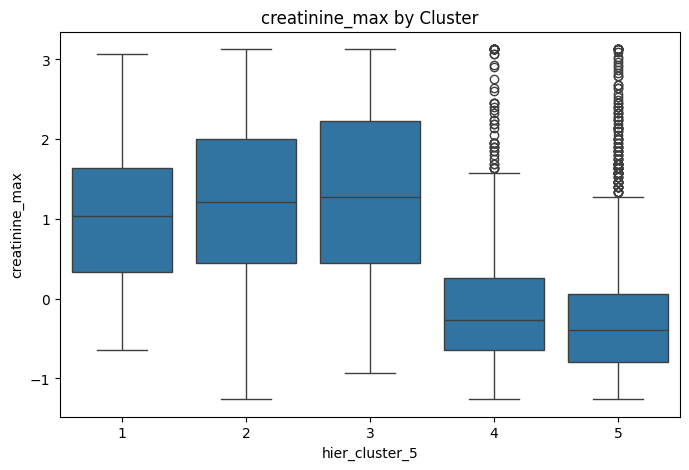

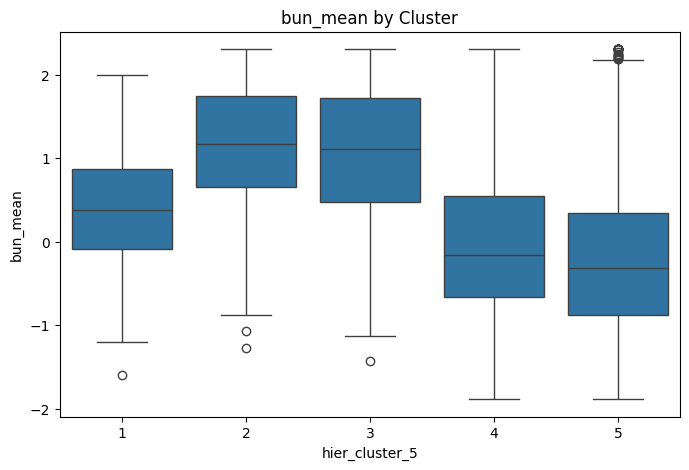

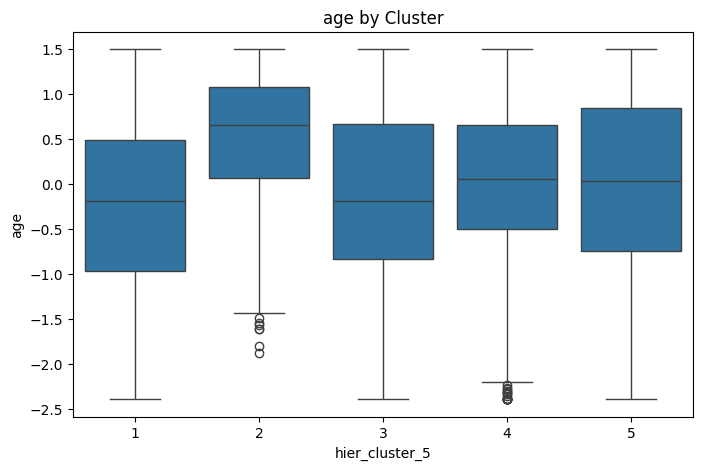

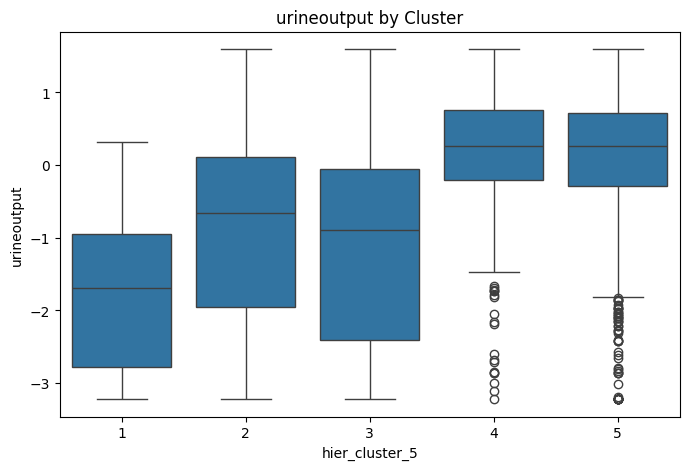

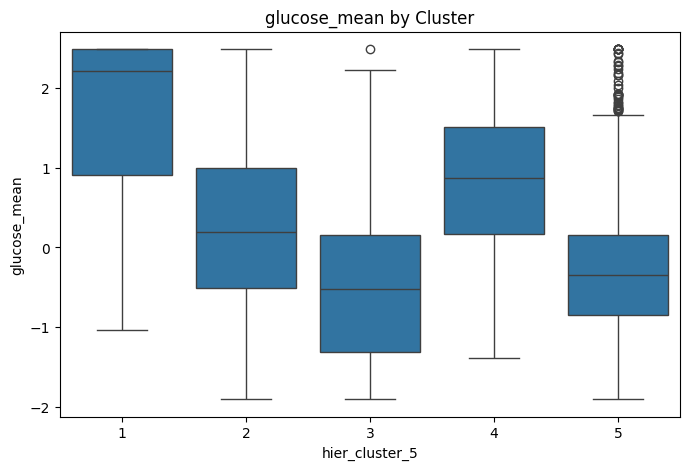

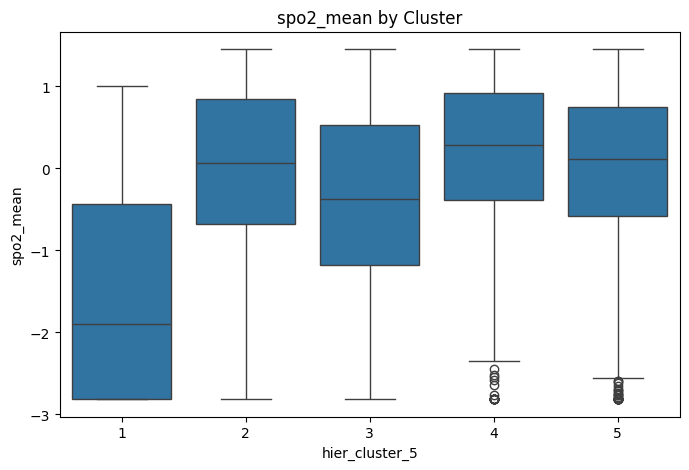

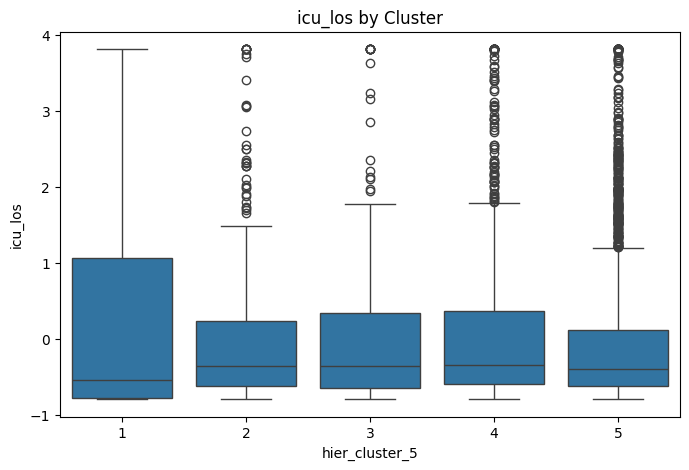

In [64]:
features = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
            'urineoutput', 'glucose_mean', 'spo2_mean', 'icu_los']

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='hier_cluster_5', y=feature, data=X_cluster_df_hierarchical)
    plt.title(f"{feature} by Cluster")
    plt.show()

- SOFA: Mean SOFA scores are highest in cluster 1, indicating more organ dysfunction, and lowest in cluster 5.

- Lactate & creatinine: Both are markedly elevated in cluster 1, consistent with severe metabolic and renal stress. Clusters 2 and 3 show moderately high creatinine.

- BUN & urine output: Cluster 1 again stands out with elevated BUN and markedly reduced urine output, suggesting possible volume overload or kidney injury.

- Age: Cluster 2 includes older patients on average, whereas clusters 1, 3, and 5 tend to be younger.

- Glucose & SpO₂: Cluster 1 has the highest glucose and lowest SpO₂, reflecting metabolic stress and hypoxia. Other clusters show more moderate values.

- ICU length of stay: Longer in cluster 1, somewhat prolonged in cluster 2, and shortest in clusters 4 and 5, aligning with overall lower severity.

**PCA visualization of clusters**

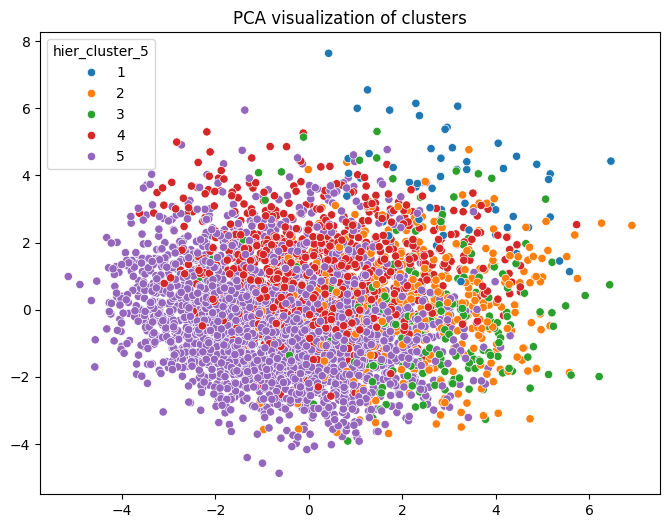

In [65]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_only_hierarchical)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_cluster_df_hierarchical['hier_cluster_5'], palette='tab10')
plt.title('PCA visualization of clusters')
plt.show()

The PCA plot shows that while the clusters overlap substantially, highlighting the complexity and shared features among patients, some patterns emerge. Cluster 1 appears more distinct, whereas clusters 2, 3, 4, and 5 are more intermingled. This indicates that the hierarchical clustering captures meaningful differences, but the clinical profiles still share considerable similarity in this reduced space.

**Clinical interpretation**



Our hierarchical clustering analysis identified five distinct ICU patient subgroups based on organ dysfunction markers, metabolic parameters, and clinical characteristics. These clusters exhibit meaningful differences that align with varying degrees of illness severity and outcomes:

Cluster 1

Displays the highest SOFA scores, markedly elevated lactate, creatinine, and glucose levels, along with the lowest urine output and SpO₂.

Also shows a high proportion requiring mechanical ventilation.

This cluster experienced the longest ICU stays and highest 30-day mortality, suggesting a critically ill phenotype with severe multi-organ dysfunction.

Cluster 2

Characterized by moderately elevated SOFA, creatinine, and BUN, but with comparatively lower lactate and higher hemoglobin levels.

Urine output is modestly reduced, and ventilation use is frequent.

Mortality is intermediate, indicating a group with predominantly renal dysfunction without overt metabolic collapse, representing a moderately high-risk cohort.

Cluster 3

Shows slightly higher creatinine and glucose, moderate SOFA and lactate, and elevated ventilation needs.

Despite these lab trends, mortality is somewhat lower than Cluster 2, with modestly shorter ICU stays, possibly reflecting respiratory/metabolic stress with partial compensation.

Cluster 4

Has lower SOFA, lactate, and creatinine values, near-normal urine output, and modest glucose levels.

This cluster includes patients of slightly younger age, with lower ventilation requirements.

Outcomes reveal shorter ICU LOS and lower mortality, suggesting a lower-acuity phenotype.

Cluster 5

Demonstrates the lowest SOFA and lactate levels, relatively preserved kidney markers (creatinine and BUN), and stable glucose and SpO₂.

Maintains the highest urine output with minimal ventilation needs.

Correspondingly, this cluster had the lowest 30-day mortality and shortest ICU stays, representing a low-risk, near-normal physiological group.

These insights highlight how hierarchical clustering can uncover clinically meaningful ICU subpopulations with differing organ dysfunction patterns and prognoses. Such stratification may aid in early identification of high-risk patients, informing targeted surveillance and potentially personalized interventions.

**Comparison of clustering approaches**

K-means clustering (k=4) produced clear patient groups with substantial differences in SOFA, renal markers (creatinine, BUN), lactate, urine output, and mortality. The clusters were relatively balanced, with easily interpretable phenotypes ranging from low to high risk.

Hierarchical clustering (k=5) identified more granular subgroups, including a very high-risk cluster with extreme metabolic and organ dysfunction, and a very low-risk cluster with near-normal physiology. However, overlap between several clusters (as seen in PCA and t-SNE) was still notable.

Statistical separation: Both algorithms revealed significant differences across key clinical variables (ANOVA and chi-squared p < 0.0001), supporting meaningful stratification. Tukey HSD and pairwise chi-squared tests showed slightly tighter pairwise separation in k-means for mortality and ICU LOS, while hierarchical clustering provided finer splits on metabolic markers.

**Which is better?**

Overall, k-means provided slightly clearer and more stable clinical phenotypes with fewer clusters, which may be more practical for bedside interpretation and early risk stratification. However, the hierarchical model uncovered additional subtle subgroups (e.g., distinguishing patients with isolated metabolic stress), which could be valuable for exploratory purposes.

**Conclusion:**

Given the trade-offs, we recommend using the k-means solution (k=4) for primary stratification due to its clearer separation and simpler interpretability, while keeping the hierarchical clusters as a complementary analysis to explore potential nuanced subtypes.